In [18]:
# 1. List of all fednews_themes (in order)
fednews_themes = [
    "Emotional response",
    "Post-layoff precarities",
    "Career trajectory",
    "Collective resistance",
    "Individual survival strategy",
    "Weaponized system",
    "Weaponizing vulnerability"
]

# 2. List of all codes (in order of fednews_themes)
fednews_all_codes = [
    # Emotional response
    "Fear/Anxiety",
    "Anger/Blame",
    "Indifference/Humor",
    "Confusion/Surprise",
    "Frustration/Disappointment",
    # Post-layoff precarities
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse",
    # Career trajectory
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change",
    # Collective resistance
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott/protest",
    "Solidarity and appreciation",
    "Whistleblowing",
    # Individual survival strategy
    "Job search",
    "Seeking legal advice",
    "Personal exit strategy",
    "Self documentation",
    # Weaponized system
    "Responsibility Obfuscation",
    "Compliance Weaponization",
    "Policy Gaslighting",
    # Weaponizing vulnerability
    "Probationary targeting",
    "Disability penalties",
    "Immigrant weaponization"
]

fednews_emotional_response = [
    "Fear/Anxiety",
    "Anger/Blame",
    "Indifference/Humor",
    "Confusion/Surprise",
    "Frustration/Disappointment"
]
fednews_post_layoff_precarities = [
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse"
]
fednews_career_trajectory = [
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change"
]
fednews_collective_resistance = [
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott/protest",
    "Solidarity and appreciation",
    "Whistleblowing"
]
fednews_individual_survival_strategy = [
    "Job search",
    "Seeking legal advice",
    "Personal exit strategy",
    "Self documentation"
]
fednews_weaponized_system = [
    "Responsibility Obfuscation",
    "Compliance Weaponization",
    "Policy Gaslighting"
]
fednews_weaponizing_vulnerability = [
    "Probationary targeting",
    "Disability penalties",
    "Immigrant weaponization"
]

In [13]:
import json
jsonl_file = "fednews_10k_posts_with_post_id_and_labels.jsonl"  # Replace with your actual file path

code_set = set()

with open(jsonl_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            try:
                entry = json.loads(line)
                for code in entry.get("codes", []):
                    code_set.add(code)
            except json.JSONDecodeError:
                print("Error decoding JSON line:", line.strip())
                continue
# Final output
print("Unique Codes Found:")
for code in sorted(code_set):
    print("-", code)
print(f"\nTotal unique codes: {len(code_set)}")


Unique Codes Found:
- Anger/Blame
- Anticipation & job insecurity
- Career change
- Compliance Weaponization
- Confusion/Surprise
- Disability penalties
- Family struggle
- Fear/Anxiety
- Financial insecurity
- Frustration/Disappointment
- Immigrant weaponization
- Immigration limbo
- Indifference/Humor
- Job search
- Job-search friction
- Legal mobilization
- Organizing boycott/protest
- Personal exit strategy
- Policy Gaslighting
- Probationary targeting
- Professional identity collapse
- Resource-sharing
- Responsibility Obfuscation
- Seeking legal advice
- Self documentation
- Solidarity and appreciation
- Whistleblowing

Total unique codes: 27


## checking for missing code

In [14]:
missing_codes = code_set - set(fednews_all_codes)  # Codes in code_set but not in fednews_all_codes
print(f"Missing Codes: {missing_codes}")

Missing Codes: set()


In [11]:
import json

# file path to your jsonl file
#file_path = "your_file.jsonl"

# missing codes you mentioned
missing_codes = {
    "Individual survival strategy"
}

# store results as {code: [post_ids]}
code_to_posts = {code: [] for code in missing_codes}

with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        post_id = data.get("post_id")
        codes = data.get("codes", [])
        
        for code in codes:
            if code in missing_codes:
                code_to_posts[code].append(post_id)

# print results
for code, posts in code_to_posts.items():
    print(f"{code}: {posts}")


Individual survival strategy: []


## visuals

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# === Step 1: Load JSONL file ===
# Replace with your actual file path
jsonl_file = "fednews_10k_posts_with_post_id_and_labels.jsonl"

df = pd.read_json(jsonl_file, lines=True)

# Ensure 'date' is datetime and derive 'month'
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_257196/2752385010.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")


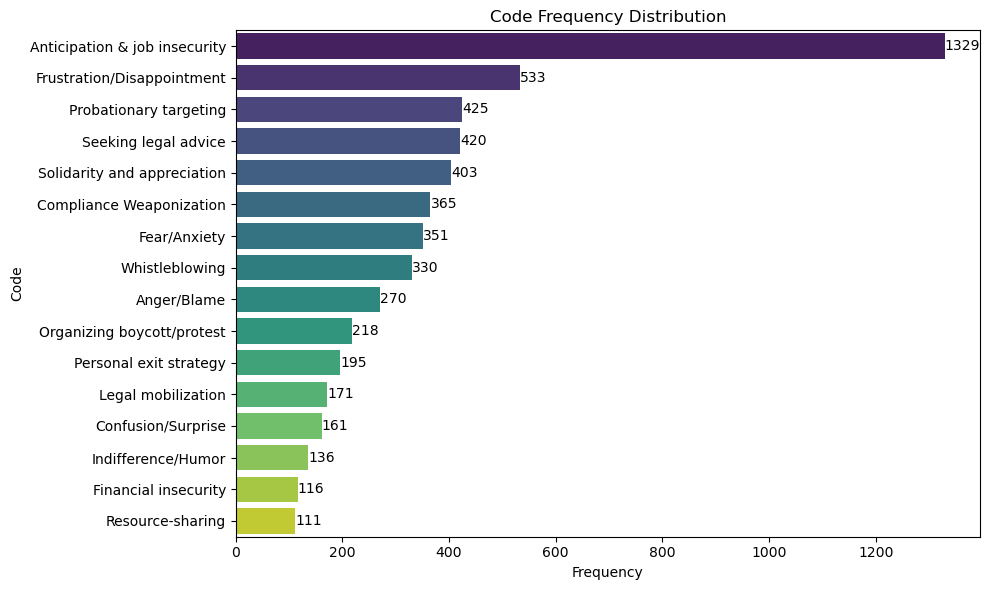

codes
Anticipation & job insecurity    1329
Frustration/Disappointment        533
Probationary targeting            425
Seeking legal advice              420
Solidarity and appreciation       403
Compliance Weaponization          365
Fear/Anxiety                      351
Whistleblowing                    330
Anger/Blame                       270
Organizing boycott/protest        218
Personal exit strategy            195
Legal mobilization                171
Confusion/Surprise                161
Indifference/Humor                136
Financial insecurity              116
Resource-sharing                  111
Name: count, dtype: int64


/tmp/ipykernel_257196/2752385010.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")


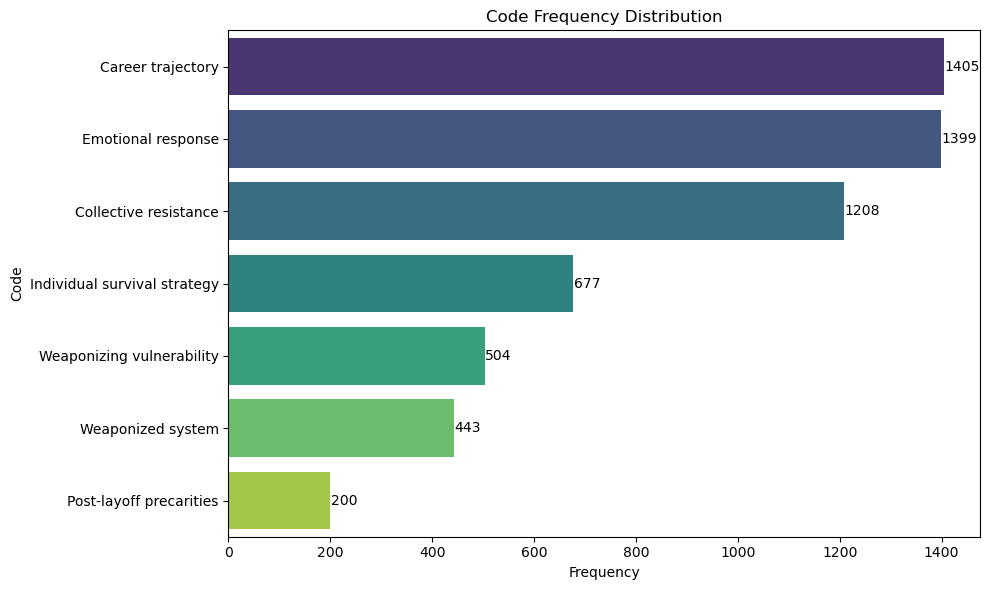

themes
Career trajectory               1405
Emotional response              1399
Collective resistance           1208
Individual survival strategy     677
Weaponizing vulnerability        504
Weaponized system                443
Post-layoff precarities          200
Name: count, dtype: int64


In [21]:



# Code frequency bar chart
fednews_all_codes = df['codes'].explode()
code_freq = fednews_all_codes.value_counts().sort_values(ascending=False)
# only keep codes with more than 100 occurrences
code_freq = code_freq[code_freq > 100]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(code_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(code_freq)



# theme frequency bar chart
all_fednews_themes = df['themes'].explode()
theme_freq = all_fednews_themes.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(theme_freq)

# save code frequency to CSV
code_freq.to_csv("code_frequency.csv", header=True)
# save theme frequency to CSV
theme_freq.to_csv("theme_frequency.csv", header=True)


/tmp/ipykernel_120749/3767850500.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")


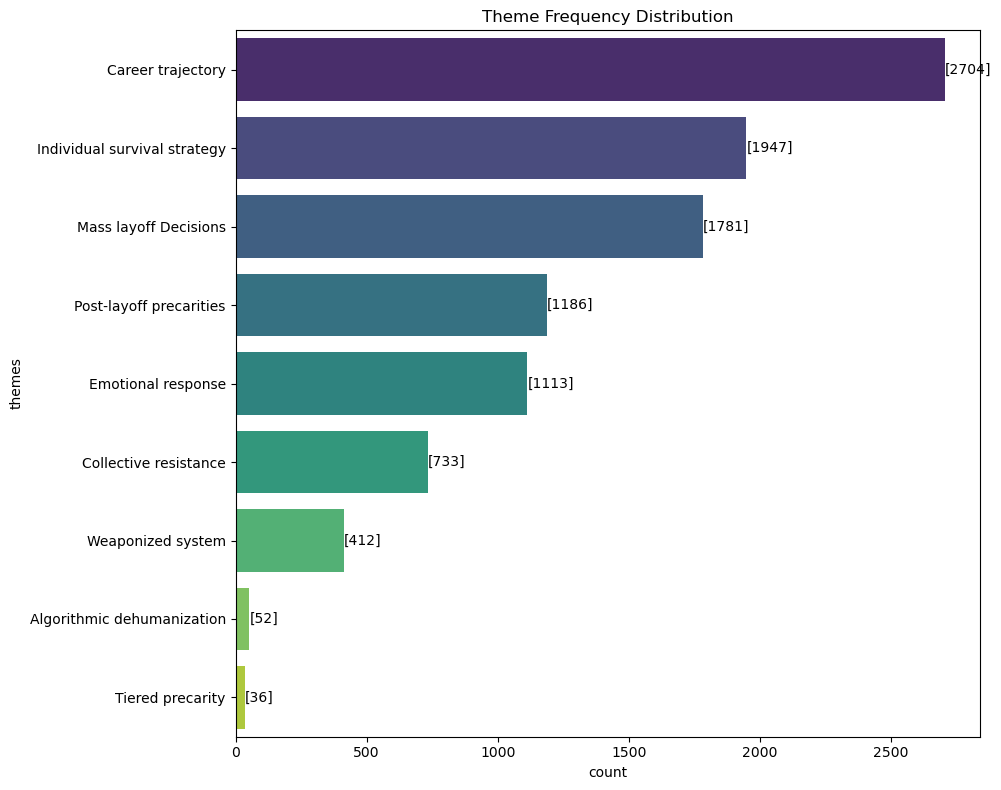

In [8]:
## generate theme frequency bar chart from theme_frequency.csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load theme frequency data
theme_freq = pd.read_csv("theme_frequency.csv", index_col=0)
theme_freq = theme_freq.sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")
plt.title("Theme Frequency Distribution")
# plt.xlabel("Frequency")
# plt.ylabel("Theme")
plt.tight_layout()  

for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.8, i, str(v), color='black', va='center')

plt.show()

In [23]:
import numpy as np
# Initialize empty co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=fednews_all_codes, columns=fednews_all_codes)

# Fill matrix from code list per post
for code_list in df['codes']:
    for c1, c2 in combinations(code_list, 2):
        co_occurrence.at[c1, c2] += 1
        co_occurrence.at[c2, c1] += 1
    for c in code_list:
        co_occurrence.at[c, c] += 1  # include diagonal

print("Co-occurrence matrix shape:", co_occurrence.shape)
# save the co-occurrence matrix to CSV
co_occurrence.to_csv("co_occurrence_matrix.csv", header=True)

# Apply log scale for better contrast
log_scaled = np.log1p(co_occurrence)

# Create mask for upper triangle
mask = np.tril(np.ones_like(log_scaled, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(log_scaled, mask=mask, cmap="YlGnBu", square=True,
            linewidths=0.5, cbar_kws={"label": "log(1 + count)"})
plt.title("Code Co-occurrence Heatmap (log scale, lower triangle)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [25]:
# === Step 5: Monthly Trends for Selected Codes ===

def plot_monthly_trends(df, sample_codes):
    df_exploded = df.explode('codes')
    monthly_trends = (
        df_exploded[df_exploded['codes'].isin(sample_codes)]
        .groupby(['month', 'codes'])
        .size()
        .unstack(fill_value=0)
    )

    monthly_trends.plot(kind='line', marker='o', figsize=(10, 6))
    plt.title("Monthly Trends of Selected Codes")
    plt.xlabel("Month")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

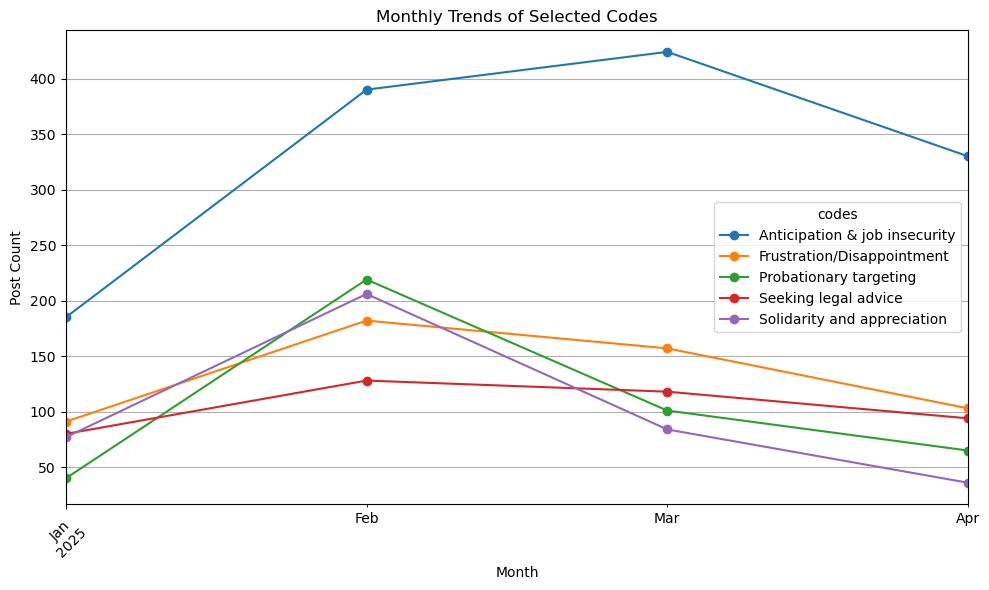

In [28]:
top_5_codes = ["Anticipation & job insecurity", "Frustration/Disappointment", "Probationary targeting", "Seeking legal advice", "Solidarity and appreciation"]
plot_monthly_trends(df, top_5_codes)


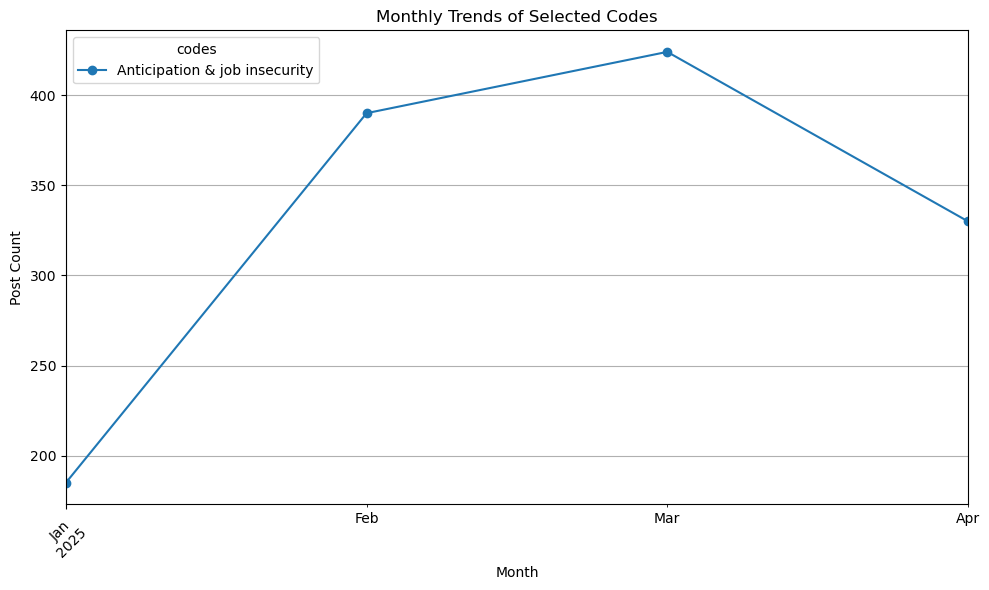

In [27]:
# digging deeper
top_2_codes = ["Anticipation & job insecurity", "News of mass layoff"]
plot_monthly_trends(df, top_2_codes)